In [ ]:
!apt-get update
!apt-get install -y zstd pciutils

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.1 MB]
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRe

In [ ]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [ ]:
import threading
import subprocess
import time

def run_ollama_serve():
  subprocess.Popen(["ollama", "serve"])

thread = threading.Thread(target=run_ollama_serve)
thread.start()
time.sleep(5)

In [ ]:
!ollama pull llama3.2-vision

In [ ]:
!pip install langchain-ollama

In [ ]:
!pip install -q colab-xterm
!pip install -q ollama

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 9.5 MB/s eta 0:00:00


In [ ]:
import ollama
from IPython.display import display, Markdown
from google.colab import files

def promptDesign(question,answer):
  content = f"""

      Context: You are a medical imaging expert specializing in radiology. your task is to analyze the given medical image,question and answer carefully to generate CoT thinking steps to reach the proper answer.


      Task instruction: You need to follow following thinking steps to generate your reasoning:
            1. Analyze the provided medical image carefully using structured critical thinking.
            2. Identify the imaging modality (X-ray, CT, MRI, Ultrasound, PET, etc.).
            3. Analyze the question and answer provided:
                  - QUESTION: {question}
                  - ANSWER: {answer}
            4. Generate detailed thinking steps based on the image, question, and answer.
            5. Validate why the given answer is correct using visual evidence from the image.
            6. Use modality-specific descriptors:
                  - CT: hyperdense / hypodense
                  - MRI: hyperintense / hypointense
                  - Ultrasound: echogenic / anechoic
            7. If findings are ambiguous, state your confidence level instead of guessing.
            8. Your response MUST strictly follow the Output Thinking Step Format below.




      Output thinking step format:
        STEP 1: IMAGE MODALITY IDENTIFICATION
            - What imaging technique was used? (X-ray, CT, MRI, Ultrasound, PET, etc.)
            - What are the visual cues that confirm this? (grayscale range, texture, artifact patterns)
            - Is contrast enhancement present?

        STEP 2: ANATOMICAL REGION & ORIENTATION
            - Which body region/organ system is depicted?
            - What is the imaging plane/view? (axial, coronal, sagittal, AP, lateral, etc.)
            - Identify key anatomical landmarks visible.

        STEP 3: SYSTEMATIC IMAGE SURVEY
            - Scan the image systematically (e.g., center-to-periphery or region-by-region).
            - Note: density/signal intensities, tissue boundaries, symmetry, size/shape of structures.
            - Use appropriate descriptors: hyperdense/hypodense (CT), hyperintense/hypointense (MRI), echogenic (US).
        STEP 4: ABNORMALITY DETECTION
            - List ALL visible abnormalities:
              * Location (specific anatomical site)
              * Size/extent (if estimable)
              * Morphology (shape, margins, borders)
              * Density/signal characteristics
              * Associated findings (mass effect, edema, calcification, etc.)
            - Note any relevant NEGATIVE findings (absence of expected structures).

       STEP 5: DIFFERENTIAL DIAGNOSIS REASONING
            - Based on findings, list possible diagnoses ranked by likelihood.
            - For each: explain which visual features support or contradict it.
            - Apply relevant clinical reasoning (e.g., distribution pattern, typical demographics).

       STEP 6: CORRELATION WITH QUESTION
            - Re-read the question: {question}
            - Which findings directly answer this question?
            - Eliminate irrelevant differentials based on what is specifically being asked.

      STEP 7: ANSWER VALIDATION
            - The provided answer is: {answer}
            - Does the image evidence support this answer? Explain why.
            - Which specific visual features are the KEY indicators for this answer?
            - Are there any alternative interpretations? Why are they less likely?

      STEP 8: FINAL REASONING SUMMARY
            - Concisely summarize the critical reasoning chain:
              [Image type] → [Key finding] → [Clinical implication] → [Answer]




      Output thinking step format:

        1. image type decide.
        2. analyze the image
        3. location wise analyze
        4. Identify the abnormalities.
        .....

      """
  return content;





# """
#             You are a medical imaging expert specializing in radiology.

#             Analyze the given medical image carefully and answer the question using step-by-step clinical reasoning.

#             Follow this structured process:

#             1. Image Modality Identification:
#               - Identify the imaging type (e.g., X-ray, CT, MRI, Ultrasound).
#             2. Anatomical Region:
#               - Specify the body part and orientation.
#             3. Key Findings:
#               - Describe important visual features (e.g., abnormalities, densities, shapes, contrasts).
#             4. Clinical Reasoning:
#               - Explain how the observed features relate to possible medical conditions.
#             5. Answer the Question:
#               - Provide a precise and concise answer based ONLY on the image.
#             6. Uncertainty Handling:
#               - If unsure, state "insufficient visual evidence" instead of guessing.
#    """





# """
#             Analyze the image carefully using structured critical thinking.

#             Follow these steps:

#             1. Describe the image clearly (objects, people, environment).
#             2. Identify key elements and important visual details.
#             3. Explain relationships between objects in the image.
#             4. Infer possible context or scenario.
#             5. Highlight any unusual or important observations.
#             6. Answer the question logically based on the analysis.

#             Think step by step and do not jump to conclusions.
#           """


def call_llm(imagelocation, prompt):
# Run vision model
  response = ollama.chat(
      model="llama3.2-vision",
      messages=[{
          "role": "user",
          "content": prompt,
          "images": [imagelocation]
      }]
  )

  return display(Markdown(response['message']['content']))


In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

# Load dataset from Hugging Face Hub
dataset = load_dataset("flaviagiammarino/vqa-rad")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1793
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 451
    })
})


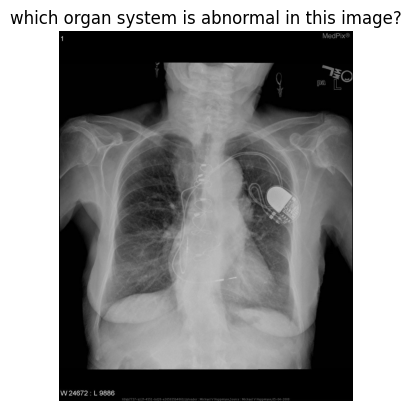

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(dataset["train"][2]["image"])
plt.axis("off")
plt.title(dataset["train"][2]["question"])
plt.show()

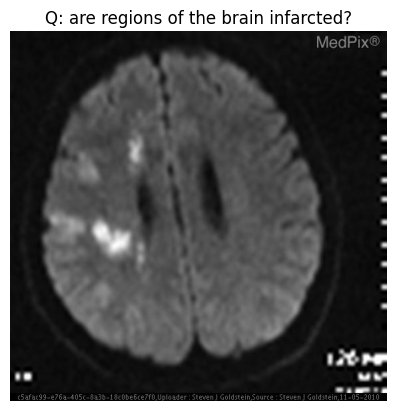


--- LLM Response for image 0 ---


**STEP 1: IMAGE MODALITY IDENTIFICATION**

*   The image appears to be an MRI scan of the brain, specifically a T1-weighted sequence.
*   This is determined by the high-resolution detail of the brain structures and the presence of a clear distinction between gray and white matter.

**STEP 2: LOCATION WISE ANALYSIS**

*   The image shows a cross-sectional view of the brain, with the frontal lobes visible at the top and the occipital lobes at the bottom.
*   The brain is divided into two hemispheres, with the corpus callosum visible as a band connecting the two.

**STEP 3: ABNORMALITY DETECTION**

*   There are several abnormalities visible in the image:
    *   **Hyperintensity in the Left Frontal Lobe**: A region of increased signal intensity is seen in the left frontal lobe, which suggests edema or infarction.
    *   **Diffuse White Matter Hyperintensity**: There is diffuse hyperintensity throughout the white matter of the brain, which may indicate demyelination or other white matter disease.
    *   **Cerebral Atrophy**: The brain appears slightly atrophic, with a loss of volume in the frontal and temporal lobes.

**STEP 4: DIFFERENTIAL DIAGNOSIS REASONING**

*   Based on the findings, the most likely diagnosis is:
    *   **Cerebral Infarction or Edema**: The hyperintensity in the left frontal lobe is consistent with an infarct or edema.
    *   **Demyelinating Disease**: The diffuse white matter hyperintensity is consistent with demyelinating diseases such as multiple sclerosis.
    *   **Cerebral Atrophy**: The atrophic appearance of the brain is consistent with various forms of atrophy, such as Alzheimer's disease or normal-pressure hydrocephalus.

**STEP 5: CORRELATION WITH QUESTION**

*   The question asks: are regions of the brain infarcted?
*   The answer is: yes
*   The hyperintensity in the left frontal lobe is consistent with an infarct or edema, which supports this answer.

**STEP 6: ANSWER VALIDATION**

*   The provided answer is: yes
*   The image evidence supports this answer, as the hyperintensity in the left frontal lobe is consistent with an infarct or edema.
*   The alternative interpretation is: no
*   This is less likely because the hyperintensity in the left frontal lobe is a clear indication of an infarct or edema.

**STEP 7: FINAL REASONING SUMMARY**

*   The image is an MRI scan of the brain, specifically a T1-weighted sequence.
*   The hyperintensity in the left frontal lobe is consistent with an infarct or edema.
*   The answer is: yes, regions of the brain are infarcted.

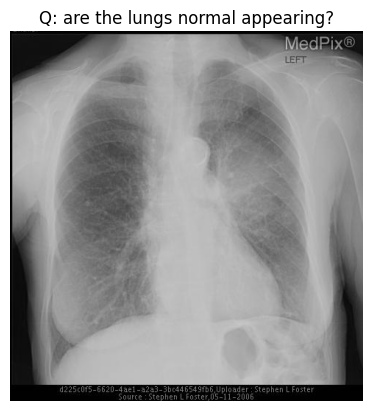


--- LLM Response for image 1 ---


**Step 1: Image Modality Identification**
The image appears to be an X-ray of the chest, specifically focusing on the lungs.

**Step 2: Anatomical Region & Orientation**
The image is an X-ray of the chest, with the patient lying on their back. The lungs are visible in the central part of the image.

**Step 3: Systematic Image Survey**
Upon reviewing the image, I notice that both lungs appear to be expanded and have a normal air-tissue interface. There are no obvious signs of pneumothorax or other lung-related issues.

**Step 4: Abnormality Detection**
I do not see any abnormalities in the lungs. Both lungs appear to be normal.

**Step 5: Differential Diagnosist Reasoning**
Based on the normal appearance of the lungs, I would not expect any specific lung-related diagnosis.

**Step 6: Correlation with Question**
The question asks if the lungs are normal appearing. Based on my analysis, both lungs appear to be normal.

**Step 7: Answer Validation**
The provided answer is: yes. The image evidence supports this answer. The normal appearance of both lungs is the key indicator for this answer.

**Step 8: Final Reasoning Summary**
X-ray of the chest → Both lungs appear normal → No specific lung-related diagnosis expected → Yes, the lungs are normal appearing.

In [ ]:
import matplotlib.pyplot as plt

# Loop first 10 samples
for i in range(2):
    sample = dataset["train"][i]

    # Save image
    imagelocation = f"temp_{i}.jpg"
    sample["image"].save(imagelocation)

    # Show image
    plt.imshow(sample["image"])
    plt.axis("off")
    plt.title(f"Q: {sample['question']}")
    plt.show()

    # Call LLM
    prompt = promptDesign(sample["question"], sample["answer"])
    print(f"\n--- LLM Response for image {i} ---")
    call_llm(imagelocation, prompt)